## 1. Carregar e Limpar os Dados
Como o dataset do Kaggle já vem pré-processado via PCA (as colunas V1 a V28), a limpeza é mínima. O foco aqui é a escala das colunas `Time` e `Amount`.


In [2]:

import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('creditcard.csv')

# Normalizando as únicas colunas que não estão em escala
scaler = StandardScaler()
df['std_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['std_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Removendo as colunas originais sem escala
df.drop(['Time', 'Amount'], axis=1, inplace=True)


In [5]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,std_amount,std_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [15]:
class_counts = df['Class'].value_counts()

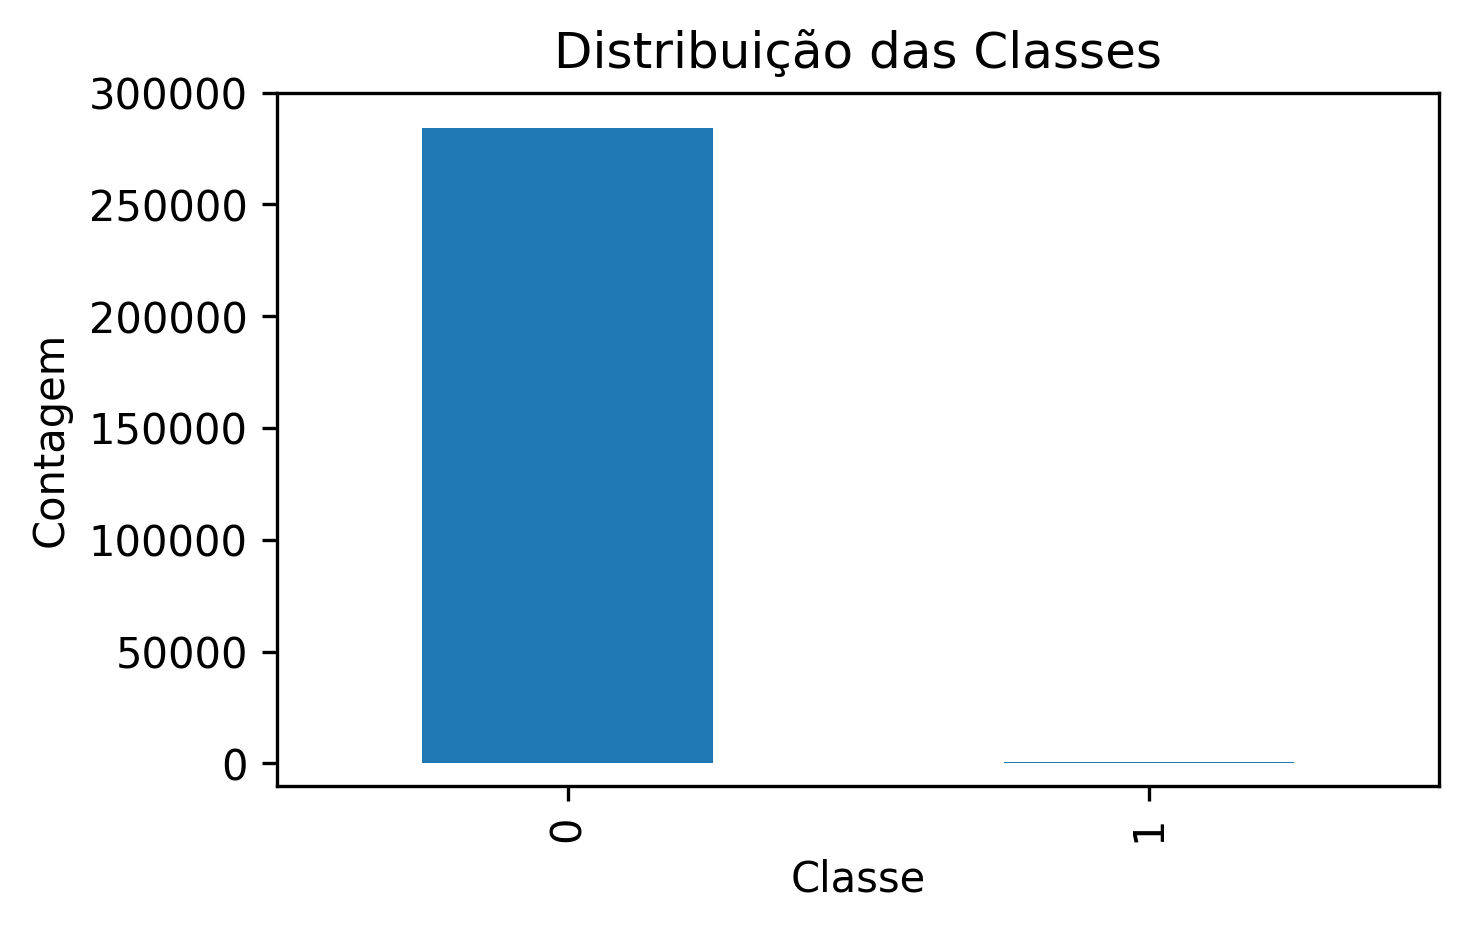

In [29]:
import matplotlib.pyplot as plt

# Plot bar chart
plt.figure(figsize=(5, 3), dpi=300)
class_counts.plot(kind='bar')
plt.ylim(-10000, 300000)
plt.title('Distribuição das Classes')
plt.xlabel('Classe')
plt.ylabel('Contagem')

plt.savefig('imagens/class_distribution.png', bbox_inches='tight')
plt.show()
plt.close()


## 2. Lidar com Dados Desbalanceados
Não use a acurácia simples! Para o treinamento, vamos separar os dados e aplicar técnicas de **Resampling** apenas no conjunto de treino para evitar o *data leakage*.

*   **SMOTE (Oversampling):** Cria dados sintéticos da classe minoritária.
*   **UnderSampling:** Remove dados da classe majoritária.



## 3. Sugestão de Modelos e Métricas
Para fraudes, métricas de erro tipo II (falsos negativos) são críticas.

*   **Modelos Baseline:** Logistic Regression (rápido), Random Forest (robusto) e XGBoost/LGBM (alta performance).
*   **Métricas Chave:** 
    *   **Recall:** Garante que estamos pegando o máximo de fraudes possível.
    *   **AUPRC (Precision-Recall Curve):** Melhor que a curva ROC para dados desbalanceados.
    *   **F1-Score:** Equilíbrio entre precisão e recall.

---

## 4. Pipeline de Treinamento com Optuna
O segredo aqui é integrar o `imbalanced-learn` no Pipeline para que o SMOTE seja aplicado corretamente durante a validação cruzada.



In [3]:

import optuna
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import average_precision_score

X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

def objective(trial):
    # Sugestão de Hiperparâmetros
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    
    # Pipeline: SMOTE + Modelo
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1))
    ])
    
    # Validação cruzada focando em Precision-Recall AUC
    score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='average_precision').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10) # Aumente para 50+ em produção

print(f"Melhores parâmetros: {study.best_params}")

/home/santiago/Python_envs/env-dio/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-05-06 20:43:35,570] A new study created in memory with name: no-name-45bda91c-446c-406e-a860-096b86ee5a5d
[I 2026-05-06 20:43:49,641] Trial 0 finished with value: 0.7280273476978024 and parameters: {'n_estimators': 168, 'max_depth': 5}. Best is trial 0 with value: 0.7280273476978024.
[I 2026-05-06 20:43:58,545] Trial 1 finished with value: 0.7111666466612943 and parameters: {'n_estimators': 121, 'max_depth': 4}. Best is trial 0 with value: 0.7280273476978024.
[I 2026-05-06 20:44:52,925] Trial 2 finished with value: 0.8115591927037534 and parameters: {'n_estimators': 386, 'max_depth': 10}. Best is trial 2 with value: 0.8115591927037534.
[I 2026-05-06 20:45:06,995] Trial 3 finished with value: 0.7956362618275605 and

Melhores parâmetros: {'n_estimators': 386, 'max_depth': 10}



## 5. Avaliação Final
Após encontrar os melhores parâmetros com o Optuna, treine o modelo final e visualize a **Matriz de Confusão**.



              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.98      0.90      0.94     56962
weighted avg       1.00      1.00      1.00     56962



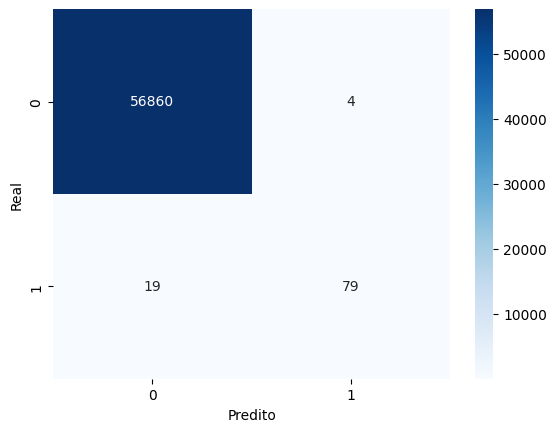

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_model = RandomForestClassifier(**study.best_params)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))


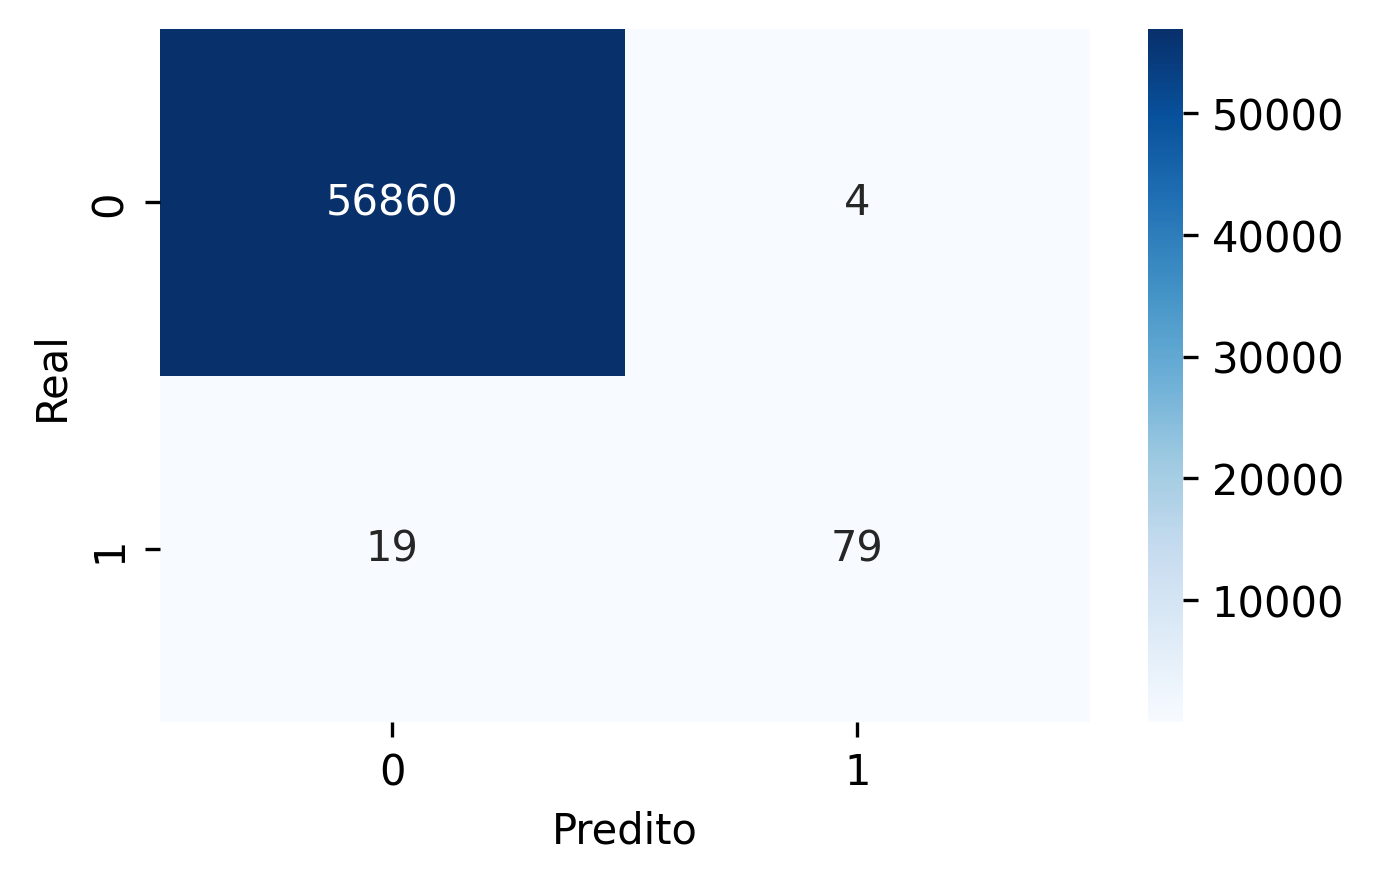

In [22]:
fig = plt.figure(figsize=(5,3), dpi=300)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.savefig('imagens/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

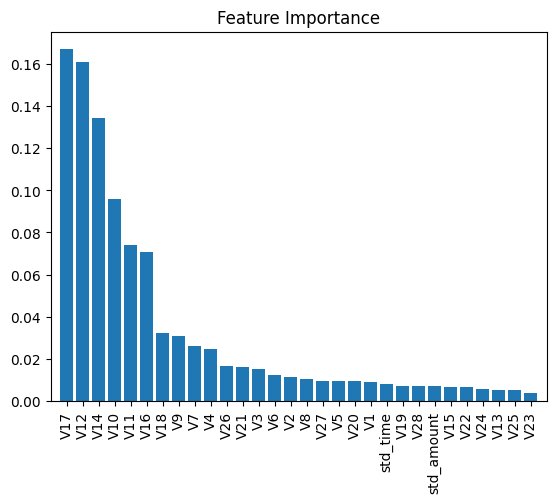

In [ ]:
import numpy as np
# Get feature importance from the RandomForestClassifier
importances = best_model.feature_importances_

# Sort feature importances in descending order and get feature names
indices = np.argsort(importances)[::-1]
names = X.columns[indices]


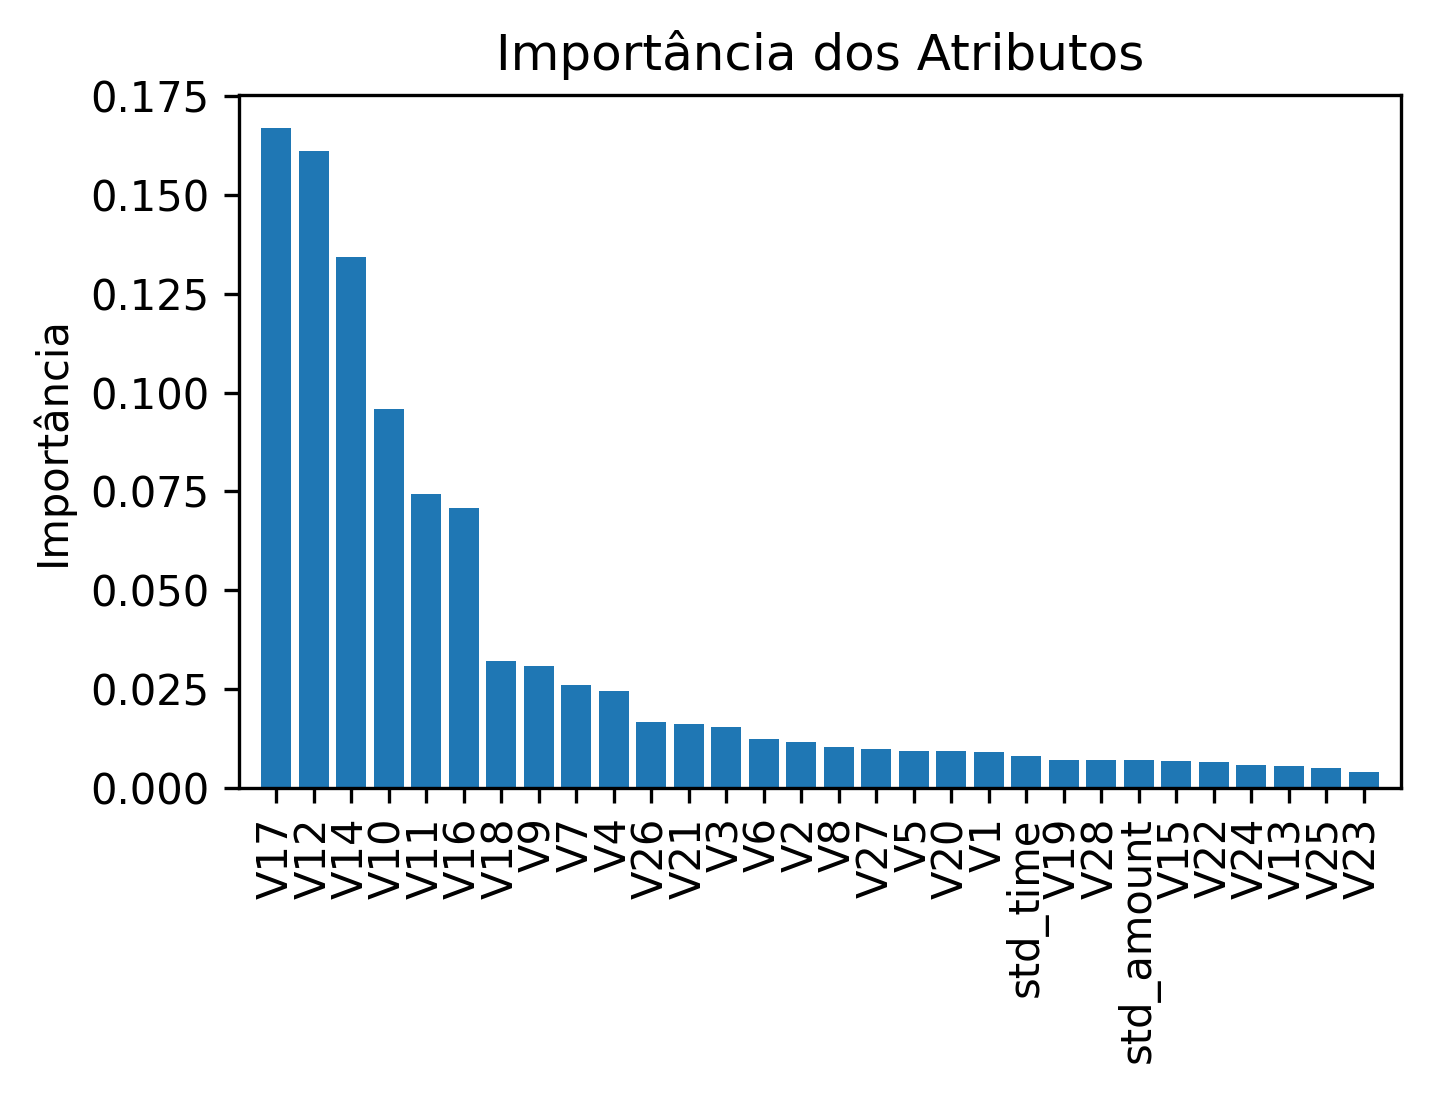

In [31]:

# Plotting the feature importances
plt.figure(figsize=(5,3), dpi=300)
plt.title("Importância dos Atributos")
plt.ylabel("Importância")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), names, rotation=90)
plt.xlim([-1, X.shape[1]])
plt.savefig('imagens/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()